In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 20 , 10
from keras.models import Sequential
from keras.layers import LSTM , Dropout , Dense

from sklearn.preprocessing import MinMaxScaler

Reading Database

In [40]:
df = pd.read_csv('data/NSE-TATA.csv')
df.head()

,Date,Open,High,Low,Last,Close,Total Trade Quantity,Turnover (Lacs)
0,2018-10-08,208.00,222.25,206.85,216.00,215.15,4642146.0,10062.83
1,2018-10-05,217.00,218.60,205.90,210.25,209.20,3519515.0,7407.06
2,2018-10-04,223.50,227.80,216.15,217.25,218.20,1728786.0,3815.79
3,2018-10-03,230.00,237.50,225.75,226.45,227.60,1708590.0,3960.27
4,2018-10-01,234.55,234.60,221.05,230.30,230.90,1534749.0,3486.05


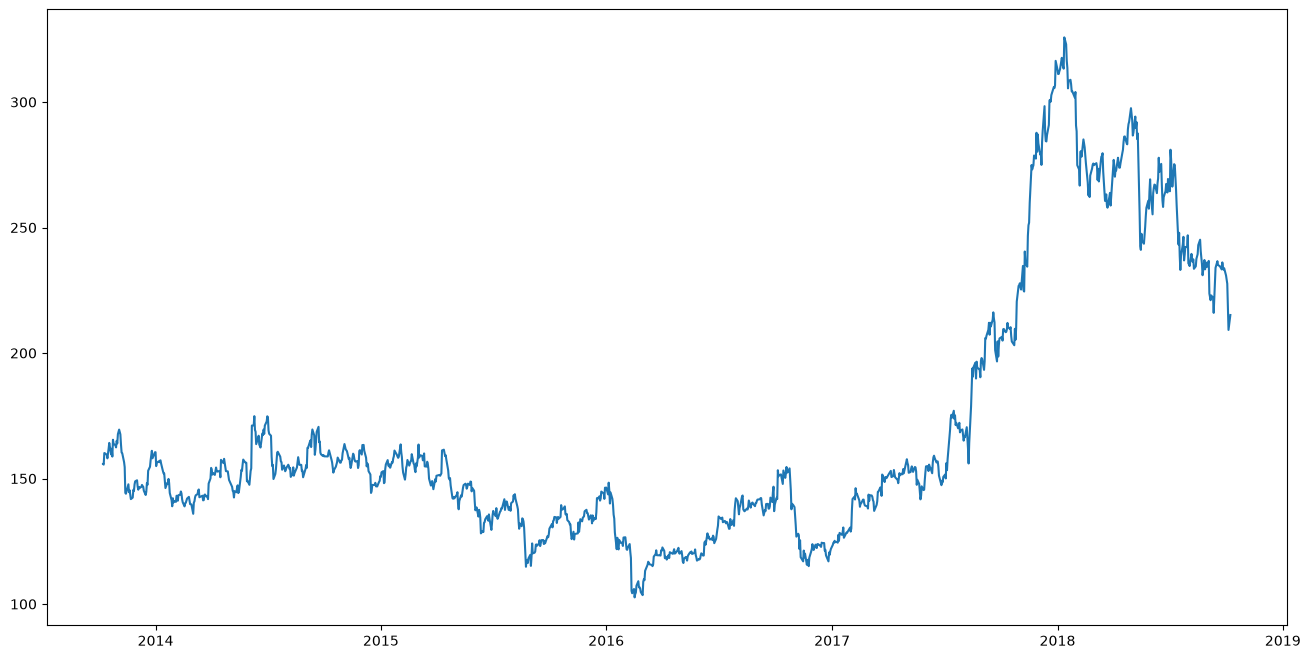

In [41]:
df['Date'] = pd.to_datetime(df.Date , format = '%Y-%m-%d')
df.index = df['Date']

plt.figure(figsize = (16,8))
plt.plot(df['Close'] ,label = 'Close Price History')

In [42]:
data = df.sort_index(ascending= True , axis = 1)
new_dataset = pd.DataFrame(index = range(0 , len(df)) , columns = ['Date' ,'Close'])

for i in range(len(data)):
  new_dataset.at[i, 'Date'] = data['Date'].iloc[i]
  new_dataset.at[i, 'Close'] = data['Close'].iloc[i]
data = df.sort_index(ascending=True)

new_dataset = pd.DataFrame(index=range(len(df)), columns=['Date','Close'])

for i in range(len(data)):
  new_dataset.at[i, 'Date'] = data['Date'].iloc[i]
  new_dataset.at[i, 'Close'] = data['Close'].iloc[i]

In [43]:
if 'Date' in new_dataset.columns:
    new_dataset.index = new_dataset['Date']
    new_dataset = new_dataset.drop("Date", axis=1)

final_dataset = new_dataset[['Close']].values

train_data = final_dataset[0:987, :]
valid_data = final_dataset[987:, :]

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(final_dataset)

x_train_data,y_train_data=[],[]

for i in range(60,len(train_data)):
    x_train_data.append(scaled_data[i-60:i,0])
    y_train_data.append(scaled_data[i,0])

x_train_data,y_train_data=np.array(x_train_data),np.array(y_train_data)

#changing dimensions is x-train-date
x_train_data=np.reshape(x_train_data,(x_train_data.shape[0],x_train_data.shape[1],1))

Building And Training LSTM Model

In [44]:
lstm_model=Sequential()
lstm_model.add(LSTM(units=50,return_sequences=True,input_shape=(x_train_data.shape[1],1)))

lstm_model.add(LSTM(units=50))
lstm_model.add(Dense(1))

inputs_data = new_dataset[len(new_dataset)-len(valid_data)-60:].values

inputs_data = inputs_data.reshape(-1,1)
inputs_data = scaler.transform(inputs_data)

lstm_model.compile( loss='mean_squared_error',optimizer='adam')
lstm_model.fit( x_train_data, y_train_data, epochs=1 , batch_size=1 ,verbose=2)

d:\Stock Prediction\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


927/927 - 37s - 39ms/step - loss: 0.0010


Taking a Sample to predict the stock prices using LSTM model

In [45]:
X_test = []
for i in range(60 , inputs_data.shape[0]):
  X_test.append(inputs_data[i-60: i , 0])

X_test = np.array(X_test)

X_test = np.reshape(X_test,(X_test.shape[0],X_test.shape[1], 1))
predicted_closing_price = lstm_model.predict(X_test)
#This is done to undo data transformation to bring back the data to its original form
predicted_closing_price = scaler.inverse_transform(predicted_closing_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step


Saving model file

In [46]:
lstm_model.save("data/saved_model.h5")

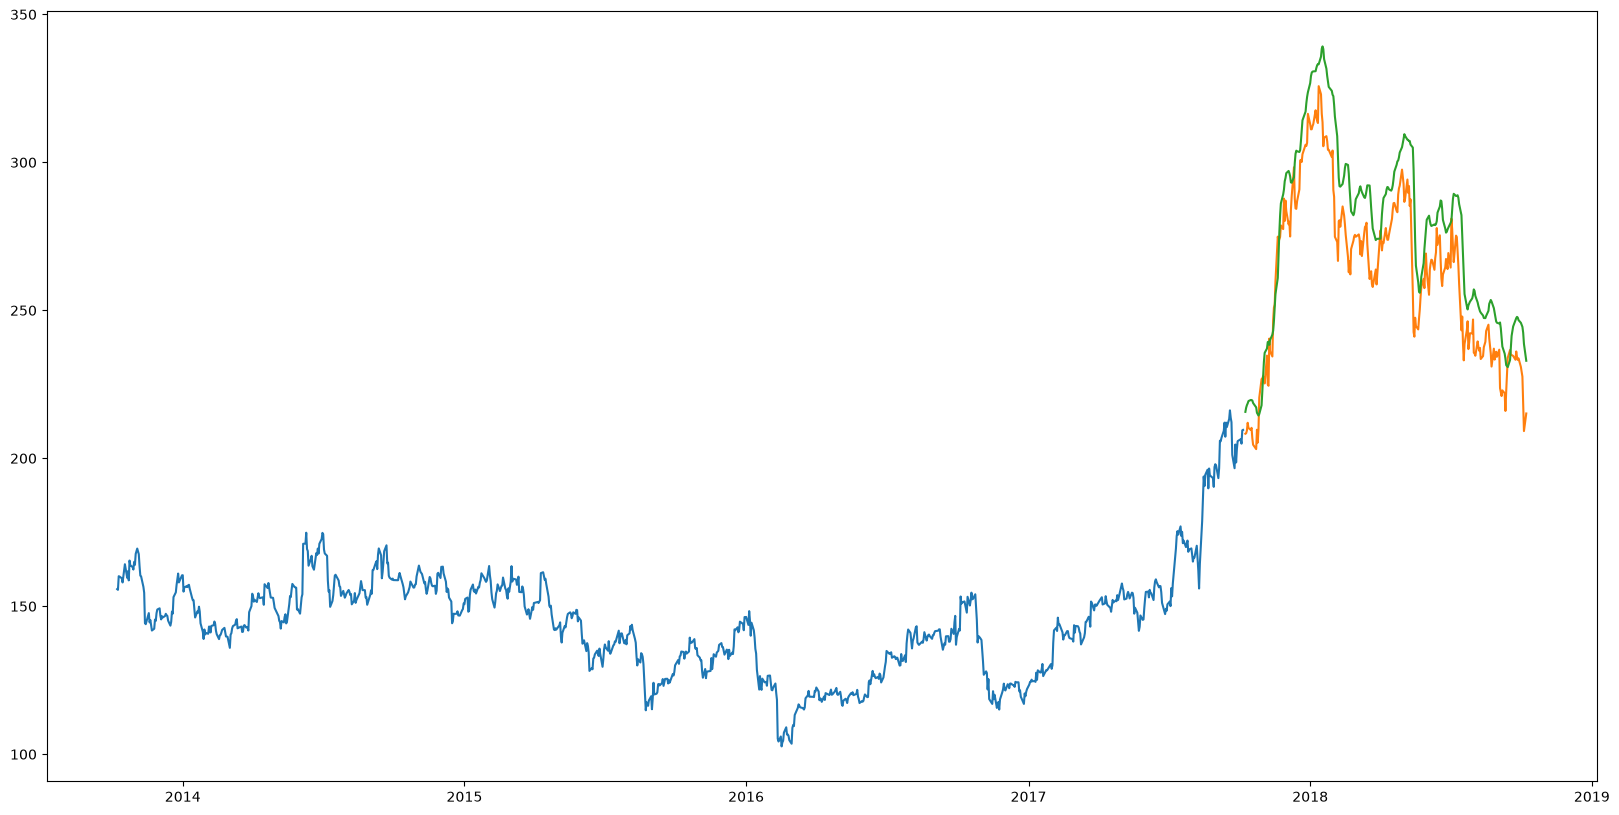

In [ ]:
train_data=new_dataset[:987]
valid_data = new_dataset[987:]

valid_data['Predictions'] = predicted_closing_price
plt.plot(train_data['Close'])
plt.plot(valid_data[['Close', 'Predictions']])